![intro](Capture.png)

## 👋 Hello, this is Nisha!

Welcome to this **End-to-End Linear Regression Case Study** 

In this notebook, I have covered Linear Regression from **basic concepts to advanced implementation** using a real-world **Food Delivery problem statement**.

This content is designed in a way that helps you:
- Understand concepts step-by-step  
- Apply them practically using Python  
- Build strong clarity for interviews  

All the code is written with proper explanations so that even beginners can follow along easily.

👉 If you face any difficulty while understanding any step, go through the explanations carefully—you will get clarity.

My goal is simple:  
**To help you not just learn Linear Regression, but confidently apply and explain it.**

Let’s get started! 🚀

Problem Statement - 

In the food delivery industry, accurately predicting delivery time is crucial for improving customer satisfaction and operational efficiency. Delivery time depends on multiple factors such as distance between the restaurant and customer, traffic conditions, weather, preparation time, and rider experience. Due to the variability of these factors, it becomes difficult to estimate delivery time manually.

The objective of this case study is to build a Linear Regression model that can predict the delivery time of an order based on these influencing factors. By understanding the relationship between input features and delivery time, we aim to generate insights that help optimize delivery operations and reduce delays.

# step 1. Import data

In [1]:
# Import required libraries

import pandas as pd          # for data handling
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt   # for visualization
import seaborn as sns        # for advanced visualization

In [2]:
# Load your dataset

df = pd.read_csv("food_delivery_dataset.csv")

# Display first 5 rows
df.head()

,Distance_km,Order_Value,Traffic_Level,Weather,Rider_Experience,Restaurant_Rating,Preparation_Time,Time_of_Day,Weekend,Delivery_Time
0,6.24,728.35,High,Rainy,9.9,3.7,28.2,Morning,1,37.09
1,14.31,582.49,Medium,Stormy,8.6,4.9,18.9,Night,1,49.67
2,11.25,378.57,High,Rainy,2.5,4.1,14.1,Afternoon,1,46.76
3,9.38,832.42,High,Clear,9.3,2.8,29.5,Night,0,38.93
4,3.18,716.26,Low,Clear,1.6,4.2,32.2,Morning,0,26.59


# Step 2 – Insights

In [4]:
 
# Check number of rows and columns
df.shape


(500, 10)

In [5]:
# Check column names
df.columns

Index(['Distance_km', 'Order_Value', 'Traffic_Level', 'Weather',
       'Rider_Experience', 'Restaurant_Rating', 'Preparation_Time',
       'Time_of_Day', 'Weekend', 'Delivery_Time'],
      dtype='object')

In [6]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Distance_km        500 non-null    float64
 1   Order_Value        500 non-null    float64
 2   Traffic_Level      500 non-null    object 
 3   Weather            500 non-null    object 
 4   Rider_Experience   500 non-null    float64
 5   Restaurant_Rating  500 non-null    float64
 6   Preparation_Time   500 non-null    float64
 7   Time_of_Day        500 non-null    object 
 8   Weekend            500 non-null    int64  
 9   Delivery_Time      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


In [7]:
# Statistical summary
df.describe()

,Distance_km,Order_Value,Rider_Experience,Restaurant_Rating,Preparation_Time,Weekend,Delivery_Time
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,7.979820,533.756500,5.273600,3.746600,25.007000,0.518000,39.289280
std,4.181815,256.944181,2.755949,0.722643,8.753483,0.500176,13.245279
min,1.070000,104.170000,0.500000,2.500000,10.000000,0.000000,5.140000
25%,4.380000,306.192500,2.800000,3.200000,17.800000,0.000000,29.672500
50%,8.185000,524.640000,5.300000,3.700000,25.050000,1.000000,39.215000
75%,11.587500,753.705000,7.700000,4.400000,32.325000,1.000000,48.270000
max,14.900000,999.750000,10.000000,5.000000,39.800000,1.000000,70.460000


Understanding the Data (Step 2 – Insights)

After loading and exploring the dataset, we gain a clear understanding of the structure and components of the data.

The dataset contains multiple features that influence the delivery time, including both numerical variables (such as distance, order value, preparation time, rider experience) and categorical variables (such as traffic level, weather conditions, and time of day). This indicates that before building the model, we will need to perform preprocessing steps like encoding categorical variables.

The target variable in this dataset is Delivery_Time, which is a continuous numerical value. This confirms that the problem is a regression problem, where the goal is to predict a numeric outcome.

From the statistical summary, we can observe the range, mean, and distribution of numerical features. This helps us understand whether the data is properly scaled and whether there are any unusual values. Since the dataset is already clean, we do not need to handle missing values, which simplifies the preprocessing step.

Additionally, by looking at the features, we can infer that delivery time is influenced by multiple real-world factors such as distance, traffic, and preparation time. This suggests that Multiple Linear Regression will be more appropriate than Simple Linear Regression for this problem.

Overall, this step helps us clearly identify:

The type of problem (Regression)
The target variable (Delivery_Time)
The input features (multiple influencing factors)
The need for preprocessing (especially encoding categorical variables)


“Understanding the data is a crucial step before modeling, as it helps in selecting the right approach and avoiding mistakes in later stages.”

# Step 3: Identify Target & Features (Explanation)

In this step, we clearly define what we want to predict and which variables we will use to make that prediction.

The target variable (also called the dependent variable) is the output we want our model to predict. In this case, the target variable is Delivery_Time, which represents the total time taken to deliver an order. Since this is a continuous numerical value, it confirms that we are solving a regression problem.

The feature variables (also called independent variables) are the inputs that influence the target variable. These include factors such as distance, traffic level, preparation time, rider experience, weather conditions, and time of day. These features provide the necessary information for the model to learn patterns and relationships.

Separating the dataset into features (X) and target (y) is an important step before model building. It ensures that the model learns only from the input variables and does not use the output variable during training.

This step is also important because it helps us:

Clearly understand what we are predicting
Identify which variables are useful for prediction
Prepare the data for model training

Simple Understanding

 Target (y) → What we want to predict (Delivery Time)
 Features (X) → Factors affecting prediction (Distance, Traffic, etc.)

 “Defining target and features correctly is crucial, as it directly impacts how well the model learns and performs"

In [8]:
# Target variable (what we want to predict)
target = "Delivery_Time"

# Features (input variables)
features = [
    "Distance_km",
    "Order_Value",
    "Traffic_Level",
    "Weather",
    "Rider_Experience",
    "Restaurant_Rating",
    "Preparation_Time",
    "Time_of_Day",
    "Weekend"
]

print("Target:", target)
print("Features:", features)

Target: Delivery_Time
Features: ['Distance_km', 'Order_Value', 'Traffic_Level', 'Weather', 'Rider_Experience', 'Restaurant_Rating', 'Preparation_Time', 'Time_of_Day', 'Weekend']


# STEP 4: Basic Data Analysis (EDA) 

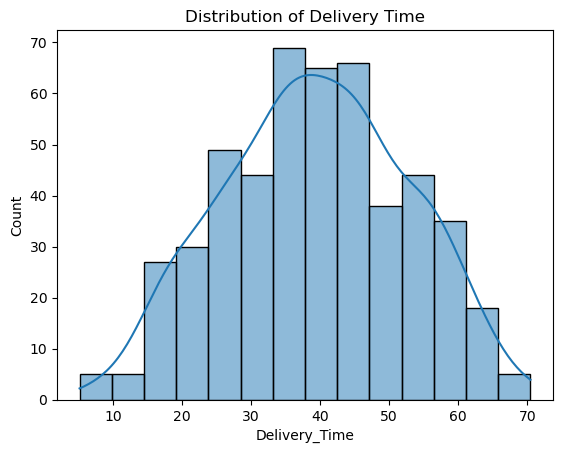

In [9]:
#4.1 Check Distribution of Target
# Distribution of Delivery Time

sns.histplot(df["Delivery_Time"], kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

How to Read above Plot
1 Center of Data (Peak) =The highest bars / peak of curve show:  Most common delivery time range

Example: If peak is around 30–40 minutes → most orders are delivered in this range

️2 Spread of Data
How wide the graph is tells: Variation in delivery time
Narrow → consistent delivery time
Wide → high variability (good learning insight)

️3 Shape of Distribution
Ideally (for Linear Regression):

Should look like a bell-shaped curve (normal distribution) .Possible Shapes & Meaning: Bell Shape (Normal Distribution) 
→ Good for Linear Regression
Right Skewed (tail on right)
→ Some deliveries take much longer (delays)
Left Skewed
→ Few unusually fast deliveries
️4 Outliers : Very high or low values (extreme bars)Indicate unusual delivery times

4.2 Relationship: Distance vs Delivery Time

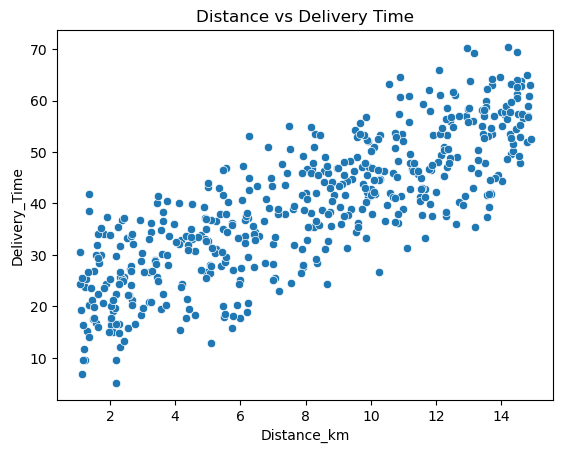

In [10]:
sns.scatterplot(x="Distance_km", y="Delivery_Time", data=df)
plt.title("Distance vs Delivery Time")
plt.show()

# What this Above graph shows
Each dot = one order
X-axis → Distance (km)
Y-axis → Delivery Time (minutes)

 It shows the relationship between distance and delivery time

 # What to Observe in This Plot
️ Relationship (MOST IMPORTANT)
 Check direction of points:If points go upward (↗) → Positive relationship

 Meaning:More distance → More delivery time 
 
️2. Linearity (Important for Linear Regression) =Check if points roughly form a straight-line pattern
Straight trend →  Linear relationship (good for model)
Curved pattern →  Non-linear (may need polynomial)

️3. Strength of Relationship

 Look how tightly points are grouped:

Close to line → Strong relationship 
Very scattered → Weak relationship 

️4. Spread (Variance)
For same distance, are delivery times similar?
Small spread → consistent delivery
Large spread → other factors (traffic, prep time) affecting

️5. Outliers

Points far away from pattern:
Very high delivery time at low distance, Indicates unusual cases (delay, traffic issue)

# Interpretation From this graph, we understand:

Distance is a key factor affecting delivery time .There is likely a positive linear relationship ,But delivery time is not only dependent on distance →Other features (traffic, prep time) also matter

4.3 Traffic Impact

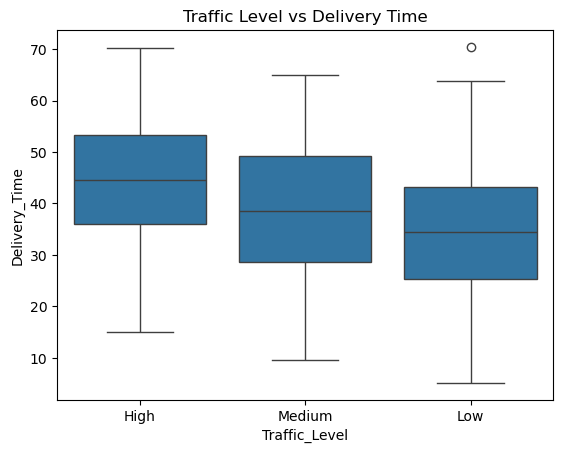

In [11]:
sns.boxplot(x="Traffic_Level", y="Delivery_Time", data=df)
plt.title("Traffic Level vs Delivery Time")
plt.show()

# What is a Boxplot Explained below refer the image :

A boxplot shows the distribution of data using 5 key values:

 Components:
Median (middle line in box)
→ Middle value of data
Box (Q1 to Q3)
→ 50% of data lies here
Lower line (min)
→ Lowest value (excluding outliers)
Upper line (max)
→ Highest value (excluding outliers)
Dots outside
→ Outliers (unusual values)

![Boxplot](boxplot.png)

# What to Understand from This Graph
1. Compare Median (MOST IMPORTANT) = Look at middle line in each box:
Low traffic → lower median
Medium traffic → higher
High traffic → highest

 Meaning:Delivery time increases with traffic level 

️2. Compare Spread (Box Size) = Bigger box = more variation
High traffic → larger box
Delivery time is less predictable in heavy traffic
️
3.Compare Range (Whiskers) =Longer lines = more variation
High traffic → longer range ,Some deliveries take much longer

️4. Outliers: Dots outside box:Very high delivery times .Shows extreme delays (maybe traffic jams, weather issues)
final Interpretation for Your Case Study

#  From this plot, we understand:

Traffic level has a strong impact on delivery time .As traffic increases → delivery time increases
High traffic introduces more variability and delays

4.4 Preparation Time Impact

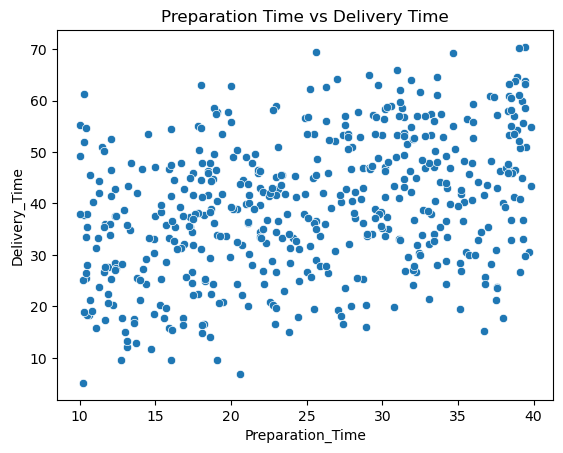

In [13]:
sns.scatterplot(x="Preparation_Time", y="Delivery_Time", data=df)
plt.title("Preparation Time vs Delivery Time")
plt.show()

What this graph shows : Each point represents: One order with its prep time and delivery time

#  What to Observe
1 Relationship (MOST IMPORTANT)
 Check direction of points:If points go upward (↗) :Positive relationship
 Meaning:More preparation time → More delivery time 

2 Linearity

Check if points follow a straight-line trend:Rough straight pattern → Good for Linear Regression
Curve → Non-linear
In this case:
Likely linear trend exists

3 Strength of Relationship
 How close points are:Close grouping → strong relationship
Scattered → weaker
Usually:Prep time shows moderate to strong relationship

4 Spread (Important Insight)
For same preparation time:Delivery time may vary
Meaning:Other factors (traffic, distance) also affect delivery

5 Outliers
Points far away:Very high delivery time with low prep time
Indicates:External delays (traffic, weather)


From this graph, we understand:

Preparation time has a direct positive impact on delivery time .It is an important predictor variable
But it is not the only factor → multiple variables influence delivery

# STEP 5: Data Preprocessing

5.1 Convert Categorical → Numerical

In [14]:
# Convert categorical variables using one-hot encoding because Machine Learning models ,
#(like Linear Regression) cannot understand text values

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Distance_km,Order_Value,Rider_Experience,Restaurant_Rating,Preparation_Time,Weekend,Delivery_Time,Traffic_Level_Low,Traffic_Level_Medium,Weather_Rainy,Weather_Stormy,Time_of_Day_Morning,Time_of_Day_Night
0,6.24,728.35,9.9,3.7,28.2,1,37.09,False,False,True,False,True,False
1,14.31,582.49,8.6,4.9,18.9,1,49.67,False,True,False,True,False,True
2,11.25,378.57,2.5,4.1,14.1,1,46.76,False,False,True,False,False,False
3,9.38,832.42,9.3,2.8,29.5,0,38.93,False,False,False,False,False,True
4,3.18,716.26,1.6,4.2,32.2,0,26.59,True,False,False,False,True,False


STEP 6: Split Data (Train-Test)

In [15]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df_encoded.drop("Delivery_Time", axis=1)
y = df_encoded["Delivery_Time"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# test_size=0.2
# 20% data → Testing
# 80% data → Training

# Example:

# Total = 500 rows
# Train = 400
# Test = 100

Training data: (400, 12)
Testing data: (100, 12)


# Explantion : The dataset is split into training and testing sets to evaluate model performance on unseen data. The model is trained on 80% of the data and tested on 20%, ensuring that it generalizes well and does not simply memorize the training data.

# STEP 7: Build Linear Regression Model

In [16]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# STEP 8: Make Predictions

In [17]:
# Predict on test data
y_pred = model.predict(X_test)

# STEP 9: Model Evaluation

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.843409777359962
MSE: 5.203494007597354
RMSE: 2.2811168333948513
R2 Score: 0.9669209686528784


# STEP 10: Residual Analysis

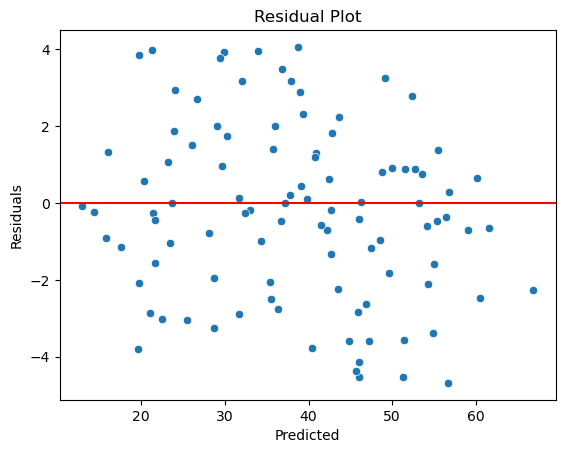

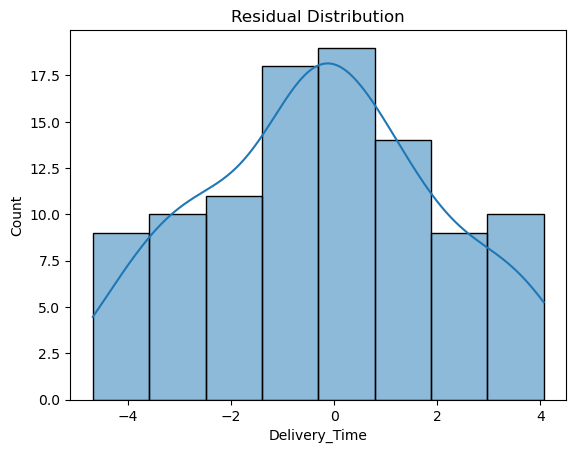

In [19]:
# Residuals
residuals = y_test - y_pred

# Scatter plot
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

# Distribution plot
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Residual analysis shows how well the model fits the data. A random scatter of residuals around zero indicates that the model captures the underlying pattern effectively. Additionally, a near-normal distribution of residuals suggests that model assumptions are satisfied and predictions are reliable .
“Residual plots help validate model assumptions. Random distribution indicates good fit, while patterns suggest model issues like non-linearity or heteroscedasticity.”


You just performed:

Data understanding
EDA
Preprocessing
Model training
Evaluation
Residual checking



# Step 11.Interpretation of Coefficients

In [20]:
# Get model coefficients 
#Coefficient tells:
#“How much the target (Delivery Time) changes when a feature increases by 1 unit (keeping others constant)”
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
9,Weather_Stormy,6.903161
8,Weather_Rainy,3.704863
0,Distance_km,2.527420
4,Preparation_Time,0.491705
5,Weekend,0.013534
1,Order_Value,-0.000091
11,Time_of_Day_Night,-0.016054
3,Restaurant_Rating,-0.142783
10,Time_of_Day_Morning,-0.473371
2,Rider_Experience,-1.272154


How to Interpret
1 Positive Coefficient  Example:
Distance_km = 2.5
 Meaning: If distance increases by 1 km , Delivery time increases by 2.5 minutes

2 Negative Coefficient Example:
Rider_Experience = -1.2
 Meaning:More experienced rider ,Delivery time decreases

3 Magnitude (Size of Value) : Larger value = stronger impact
2.5 → strong effect
0.2 → small effect

Special Case: Encoded Variables  Example:
Traffic_Level_High = 5 Meaning:High traffic increases delivery time compared to Low traffic (reference category)

Understanding from This:
# Model coefficients represent the impact of each feature on delivery time. A positive coefficient indicates an increase in delivery time, while a negative coefficient indicates a decrease. The magnitude of the coefficient reflects the strength of the relationship, helping identify the most influential features.
“Coefficients help interpret the model by showing the direction and strength of each feature’s impact on the target variable.”

 # steo 12. Ridge & Lasso Implementation

In [22]:
from sklearn.linear_model import Ridge

# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_squared_error

print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge R2: 0.966898838039474
Ridge RMSE: 2.281879764956849


In [24]:
ridge_coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

ridge_coeff.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
9,Weather_Stormy,6.777397
8,Weather_Rainy,3.596309
0,Distance_km,2.528804
4,Preparation_Time,0.491284
5,Weekend,0.005441
1,Order_Value,-0.000067
11,Time_of_Day_Night,-0.024316
3,Restaurant_Rating,-0.151147
10,Time_of_Day_Morning,-0.464375
2,Rider_Experience,-1.271251


Lasso Regression (L1)

In [25]:
from sklearn.linear_model import Lasso

# Create Lasso model
lasso_model = Lasso(alpha=0.1)

# Train model
lasso_model.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test)

In [26]:
print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso R2: 0.965104373855371
Lasso RMSE: 2.3429155525658585


In [27]:
lasso_coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

lasso_coeff.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
9,Weather_Stormy,6.047761
8,Weather_Rainy,2.799685
0,Distance_km,2.535993
4,Preparation_Time,0.489501
1,Order_Value,0.000021
3,Restaurant_Rating,-0.000000
5,Weekend,-0.000000
10,Time_of_Day_Morning,-0.000000
11,Time_of_Day_Night,0.000000
2,Rider_Experience,-1.251074


# Final Interpretation:

Ridge:Reduces impact of all features ,Helps with multicollinearity
Lasso: Removes unnecessary features (coeff = 0) ,Performs feature selection

 # Final Conclusion

In this case study, we successfully built an end-to-end Linear Regression model to predict food delivery time based on multiple real-world factors such as distance, traffic conditions, preparation time, rider experience, and weather. Through Exploratory Data Analysis (EDA), we identified meaningful relationships between these variables and the target variable, which helped in selecting the right modeling approach.

We started with a basic Linear Regression model and evaluated its performance using metrics like MAE, RMSE, and R² score. The results showed that the model was able to capture a significant portion of the variation in delivery time. By interpreting the model coefficients, we gained valuable insights into how each factor impacts delivery time—for example, distance and preparation time increase delivery time, while rider experience can help reduce it.

To further improve model performance and handle potential issues like overfitting and multicollinearity, we applied **Ridge and Lasso Regression**. Ridge helped in stabilizing the model by reducing the impact of correlated features, while Lasso helped in identifying and removing less important features through feature selection.

Residual analysis confirmed that the model assumptions were reasonably satisfied, indicating a good fit between predicted and actual values. Overall, this project demonstrates how Linear Regression can be effectively used not only for prediction but also for extracting actionable business insights.



Business Impact

 Helps estimate accurate delivery time for customers
 Improves operational planning and resource allocation
 Enhances customer satisfaction by reducing delays

Final Closing Line

 “This case study highlights how data-driven modeling can transform raw data into meaningful insights, enabling better decision-making in real-world business scenarios.”

